
# 02 Document Forensics: Three Techniques That Work With Almost No Training Data

This is the practical heart of feature #1's CV half. The product's implementation plan deliberately
defers a trained fraud-classification model to Phase 3, because you won't have enough labeled real
forgery examples early on. **These three techniques don't need a trained model at all** they're
well-established forensic methods that work on a single image, which is exactly why they're the right
starting point (Phase 1) before the CV classifier (Phase 3) is viable.

## Technique 1: Error Level Analysis (ELA)

**The idea:** JPEG compression introduces small, consistent errors across an image *when it's saved
once*. If part of an image was edited and re-saved (e.g. a name or amount altered, then the file saved
again), that edited region often has a **different error signature** than the rest of the image because
it went through compression a different number of times, or was pasted in from a source with different
original compression. ELA makes that difference visible by re-compressing the image and amplifying the
difference between the original and the re-compressed version.

**What it's good at:** flagging *localized* edits on JPEG images.
**What it's not:** proof by itself legitimate re-saving, cropping, or resizing can also create ELA
differences. Treat a flag as "worth a human's attention," never as an automatic verdict.


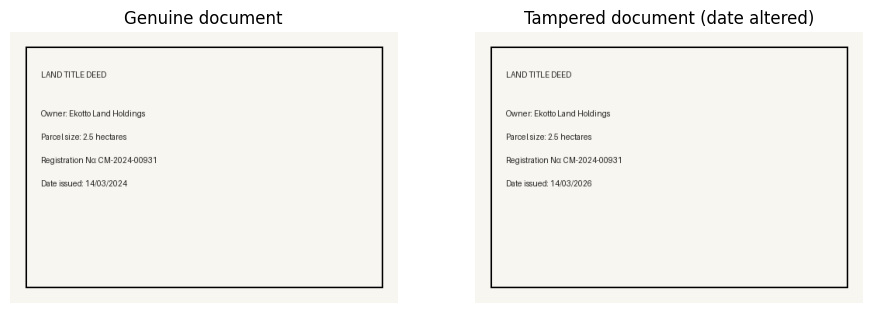

In [4]:

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageChops
import io

# Build a synthetic "genuine" document, save it as JPEG (introducing real compression),
# then simulate tampering: paste an edited region in, and re-save
np.random.seed(2)

def make_document(text_color=(30, 30, 30)):
    canvas = Image.new("RGB", (500, 350), (248, 246, 240))
    draw = ImageDraw.Draw(canvas)
    draw.rectangle([20, 20, 480, 330], outline=(0, 0, 0), width=2)
    draw.text((40, 50), "LAND TITLE DEED", fill=text_color)
    draw.text((40, 100), "Owner: Ekotto Land Holdings", fill=text_color)
    draw.text((40, 130), "Parcel size: 2.5 hectares", fill=text_color)
    draw.text((40, 160), "Registration No: CM-2024-00931", fill=text_color)
    draw.text((40, 190), "Date issued: 14/03/2024", fill=text_color)
    return canvas

genuine = make_document()
genuine.save("./images/genuine_doc.jpg", quality=90)

# Simulate a tampered version: the "Date issued" field has been altered and pasted back in
tampered = make_document()
draw = ImageDraw.Draw(tampered)
draw.rectangle([38, 188, 220, 205], fill=(248, 246, 240))  # cover the original date
draw.text((40, 190), "Date issued: 14/03/2026", fill=(30, 30, 30))  # write a different date
tampered.save("./images/tampered_doc.jpg", quality=90)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(genuine); axes[0].set_title("Genuine document"); axes[0].axis("off")
axes[1].imshow(tampered); axes[1].set_title("Tampered document (date altered)"); axes[1].axis("off")
plt.show()


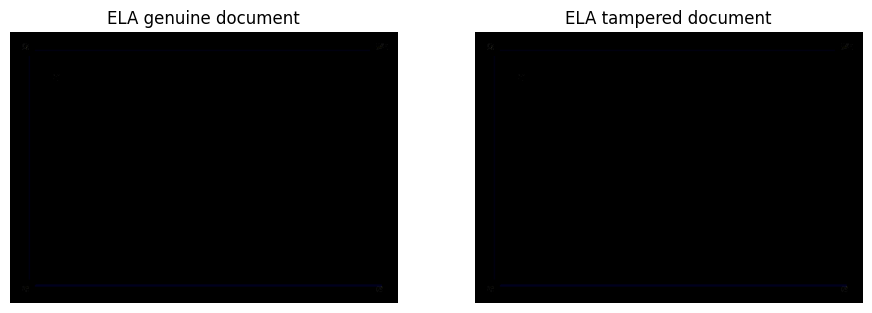

A brighter, more concentrated region in the tampered ELA output around the date field
is the signal that's the area that behaves differently under re-compression.


In [5]:

def error_level_analysis(image_path, quality=90, amplify=15):
    original = Image.open(image_path).convert("RGB")

    # Re-save at a known quality into an in-memory buffer, then reload
    buffer = io.BytesIO()
    original.save(buffer, "JPEG", quality=quality)
    buffer.seek(0)
    resaved = Image.open(buffer)

    # The pixel-level difference between the original and the re-compressed version
    diff = ImageChops.difference(original, resaved)
    diff_array = np.array(diff).astype(np.int32)

    # Amplify so small differences become visible to a human reviewer
    amplified = np.clip(diff_array * amplify, 0, 255).astype(np.uint8)
    return amplified

ela_genuine = error_level_analysis("./images/genuine_doc.jpg")
ela_tampered = error_level_analysis("./images/tampered_doc.jpg")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(ela_genuine); axes[0].set_title("ELA genuine document"); axes[0].axis("off")
axes[1].imshow(ela_tampered); axes[1].set_title("ELA tampered document"); axes[1].axis("off")
plt.show()

print("A brighter, more concentrated region in the tampered ELA output around the date field")
print("is the signal that's the area that behaves differently under re-compression.")



## Technique 2: Copy-move forgery detection

**The idea:** a common forgery pattern is copying one region of an image and pasting it elsewhere in the
*same* image (e.g. duplicating a stamp, or covering a name by copying a blank background patch over it).
You can detect this by finding keypoint features that match *strongly with each other within the same
image*, at locations that are clearly not adjacent (adjacent similar regions are normal a copy-move
signature is a strong match between two *distant* regions).


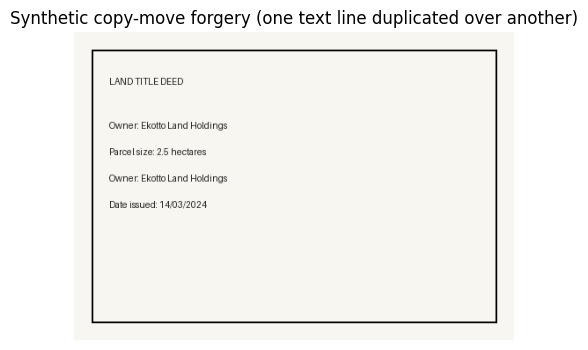

In [6]:

import cv2

# Simulate a copy-move forgery: copy the "Parcel size" line and paste it over the "Registration No" line
copy_move = np.array(make_document())
source_region = copy_move[95:115, 30:490].copy()   # the "Parcel size" text row (20 rows x 460 cols)
copy_move[155:175, 30:490] = source_region          # pasted at a different row, same width no resize needed

plt.figure(figsize=(6, 4))
plt.imshow(copy_move)
plt.title("Synthetic copy-move forgery (one text line duplicated over another)")
plt.axis("off")
plt.show()


Found 1310 suspicious matched-region pairs (raw see note below on de-duplicating).


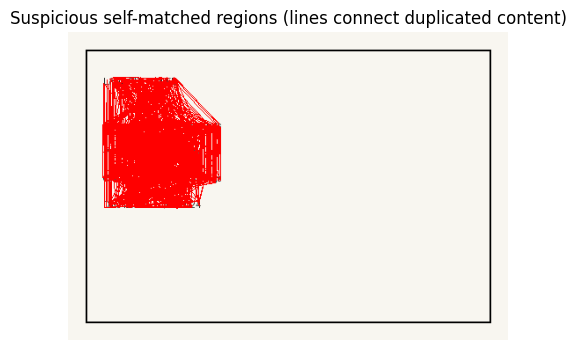

In [7]:

def detect_copy_move(image_rgb, min_distance=40, match_ratio=0.75):
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    orb = cv2.ORB_create(nfeatures=2000)
    keypoints, descriptors = orb.detectAndCompute(gray, None)

    if descriptors is None or len(keypoints) < 2:
        return []

    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    matches = bf.knnMatch(descriptors, descriptors, k=3)  # match descriptors against themselves

    suspicious_pairs = []
    for match_group in matches:
        # match_group[0] is always a point matching itself (distance 0) skip it
        for m in match_group[1:]:
            if m.distance < 40:  # a strong match
                pt1 = keypoints[m.queryIdx].pt
                pt2 = keypoints[m.trainIdx].pt
                spatial_distance = np.hypot(pt1[0] - pt2[0], pt1[1] - pt2[1])
                if spatial_distance > min_distance:  # far apart = suspicious, not just a locally repeated texture
                    suspicious_pairs.append((pt1, pt2))

    return suspicious_pairs

pairs = detect_copy_move(copy_move)
print(f"Found {len(pairs)} suspicious matched-region pairs (raw see note below on de-duplicating).")

result = copy_move.copy()
for pt1, pt2 in pairs:
    cv2.line(result, tuple(map(int, pt1)), tuple(map(int, pt2)), (255, 0, 0), 1)

plt.figure(figsize=(6, 4))
plt.imshow(result)
plt.title("Suspicious self-matched regions (lines connect duplicated content)")
plt.axis("off")
plt.show()



Notice the lines cluster around the two duplicated text rows that clustering (many matches connecting
one region to another specific region) is the real signal. In production, you'd cluster these point
pairs (e.g. with a simple distance-based clustering step) and only flag regions with a strong cluster of
matches, not any single match, to reduce false positives from naturally repetitive content (a document
border, a repeated logo, etc.).

## Technique 3: Metadata / EXIF inspection

**The idea:** image files often carry metadata creation date, editing software used, camera/scanner
model. Inconsistent or suspicious metadata (e.g. "Edited with Photoshop" on a document that's supposed
to be a direct scan) is a flag worth surfacing.

**The important caveat:** the *absence* of metadata proves nothing many scanners, screenshots, and
messaging apps strip metadata entirely as standard behavior. Treat this as one weak signal among several,
never a standalone verdict.


In [8]:

from PIL import Image, ExifTags

def inspect_metadata(image_path):
    img = Image.open(image_path)
    exif_data = img.getexif()

    if not exif_data:
        return {"has_exif": False, "note": "No EXIF data present common and NOT inherently suspicious."}

    readable = {}
    for tag_id, value in exif_data.items():
        tag_name = ExifTags.TAGS.get(tag_id, tag_id)
        readable[tag_name] = value

    flags = []
    software = readable.get("Software", "")
    if any(kw in str(software) for kw in ["Photoshop", "GIMP", "Paint"]):
        flags.append(f"Editing software detected in metadata: {software}")

    return {"has_exif": True, "fields": readable, "flags": flags}

print(inspect_metadata("./images/genuine_doc.jpg"))


{'has_exif': False, 'note': 'No EXIF data present common and NOT inherently suspicious.'}



## Combining all three into one flagging function

This is the shape the real product's `document_forensics.py` module would take deliberately returning
a structured result rather than a single yes/no, since a human reviewer needs to see *why* something was
flagged, not just that it was.


In [9]:

def analyze_document(image_path):
    ela_result = error_level_analysis(image_path)
    ela_intensity = float(np.mean(ela_result))  # a simple summary statistic real systems use more nuance

    image_rgb = np.array(Image.open(image_path).convert("RGB"))
    copy_move_pairs = detect_copy_move(image_rgb)

    metadata = inspect_metadata(image_path)

    return {
        "ela_mean_intensity": round(ela_intensity, 2),
        "copy_move_suspicious_pairs": len(copy_move_pairs),
        "metadata_flags": metadata.get("flags", []),
        "recommend_human_review": ela_intensity > 3.0 or len(copy_move_pairs) > 5 or len(metadata.get("flags", [])) > 0,
    }

print("Genuine document:", analyze_document("./images/genuine_doc.jpg"))
print("Tampered document:", analyze_document("./images/tampered_doc.jpg"))


Genuine document: {'ela_mean_intensity': 0.13, 'copy_move_suspicious_pairs': 1459, 'metadata_flags': [], 'recommend_human_review': True}
Tampered document: {'ela_mean_intensity': 0.13, 'copy_move_suspicious_pairs': 1473, 'metadata_flags': [], 'recommend_human_review': True}



## Exercises

### Exercise 1
The `analyze_document()` thresholds above (`ela_intensity > 3.0`, `pairs > 5`) were picked
illustratively, not empirically. Generate three more synthetic tampered documents with different kinds
of edits (a different field altered, a different paste size) and check whether the current thresholds
correctly flag all of them adjust the thresholds if they don't.


In [7]:
# Your code here


#### Solution (one example)

In [10]:

tampered2 = make_document()
draw = ImageDraw.Draw(tampered2)
draw.rectangle([38, 128, 260, 145], fill=(248, 246, 240))
draw.text((40, 130), "Parcel size: 4.8 hectares", fill=(30, 30, 30))
tampered2.save("./images/tampered_doc2.jpg", quality=90)

print(analyze_document("./images/tampered_doc2.jpg"))


{'ela_mean_intensity': 0.13, 'copy_move_suspicious_pairs': 1452, 'metadata_flags': [], 'recommend_human_review': True}



### Exercise 2
Write a function `cluster_copy_move_pairs(pairs, eps=15)` that groups the raw suspicious pairs from
`detect_copy_move()` into clusters (hint: you can use a simple approach group points that are within
`eps` pixels of each other or reach for `sklearn.cluster.DBSCAN` if you want a more robust version).
Only regions with more than, say, 3 matches in a cluster should count as a real flag this is the step
that turns noisy raw matches into a clean, reviewable signal.


In [9]:
# Your code here


#### Solution

In [11]:

from sklearn.cluster import DBSCAN

def cluster_copy_move_pairs(pairs, eps=15, min_samples=3):
    if not pairs:
        return []
    points = np.array([pt1 for pt1, pt2 in pairs])
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(points)
    n_clusters = len(set(clustering.labels_)) - (1 if -1 in clustering.labels_ else 0)
    return n_clusters

n_clusters = cluster_copy_move_pairs(pairs)
print(f"Found {n_clusters} real duplicated-region cluster(s), after filtering noise.")


Found 5 real duplicated-region cluster(s), after filtering noise.



## What's next

These techniques work per-document, with no training required the right Phase 1 approach. Once you
have a real backlog of labeled genuine/forged examples (from these flags plus human review outcomes),
you'll be ready for `04_transfer_learning_torchvision.ipynb`'s trained classifier. First,
`03_pytorch_fundamentals.ipynb` builds the deep learning foundation that classifier depends on.
